# Notebook 4: Numerisk præcision, parallel skalering og beregningsgrænser

I denne notebook undersøger jeg tre indbyrdes forbundne spørgsmål om phasic-bibliotekets beregningsmæssige egenskaber:

1. **Numerisk præcision (MPFR):** Hvornår fejler standard 64-bit floating-point aritmetik for Gaussisk elimination, og hvad er den faktiske numeriske fejl? Jeg undersøger condition number som funktion af modelkompleksitet og kvantificerer præcistabene.
2. **Parallel skalering:** Hvordan skalerer SVGD med antallet af CPU-kerner? Er speedup'en lineær, og hvornår dominerer overhead?
3. **Beregningsgrænser:** Hvad er den praktiske øvre grænse for prøvestørrelse og modellkompleksitet? Jeg profilerer hukommelse og tid som funktion af tilstandsrumsudvækst.

Disse tre temaer er direkte relevante for, hvad der er muligt at beregne i specialets analyser og for at forstå de begrænsninger, som fase-type-tilgangen har sammenlignet med simulationsbaserede metoder.

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    configure, get_config, get_available_options,
    init_parallel, detect_environment, get_parallel_config,
    parallel_config, disable_parallel,
    set_log_level, clear_caches,
    GaussPrior, ExpStepSize, Adam,
)  # ALWAYS import phasic first
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import tracemalloc
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

# Tjek tilgængelighed
opts = get_available_options()
print(f"MPFR tilgængeligt:    {opts['mpfr']}")
print(f"JAX devices:          {len(jax.devices())}")
print(f"Device type:          {jax.devices()[0].platform}")

  Removed 19 file(s), preserved directory structure
MPFR tilgængeligt:    True
JAX devices:          1
Device type:          cpu


## Tilstandsnummer og numerisk præcision

Gaussisk elimination på fase-type-grafer involverer multiplikatorer, der kan variere over mange størrelsesordener. Tilstandsnummer $\kappa = \max|\text{multiplikator}| / \min|\text{multiplikator}|$ er et mål for, hvor numerisk ustabil elimineringen er. Når $\kappa > 10^{12}$ aktiveres MPFR automatisk.

### Hypotese 

- Tilstandsnummer vokser lineært med prøvestørrelse $n$, fordi koalescensraterne spænder over $\binom{2}{2}=1$ til $\binom{n}{2}=n(n-1)/2$. Ved $n \geq 15$ forventes tilstandsnummer at overstige $10^{12}$, og standard 64-bit aritmetik producerer synlige fejl i højere-ordens momenter.

Jeg verificerer dette ved at sammenligne momenter beregnet med og uden MPFR.

In [2]:
def build_coalescent(n):
    """Byg standard koalescent for n prøver."""
    @with_ipv([n] + [0] * (n - 1))
    def coalescent(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    return Graph(coalescent)

# Analytisk E[H] = 2*(1-1/n)
def analytical_EH(n):
    return 2 * (1 - 1/n)

# Analytisk E[H^2] = sum_{k=2}^n 4/k^2(k-1)^2/4 ... brug graf til reference
print("Bygger koalescenter og analyserer tilstandsnummer...\n")
set_log_level('WARNING')  # Slå MPFR-advarsler fra midlertidigt

rows = []
for n in range(2, 18):
    g = build_coalescent(n)
    n_vertices = g.vertices_length()
    
    # Beregn momenter med double-precision
    configure(force_high_precision=False, condition_threshold=float('inf'))  # aldrig MPFR
    E_double = g.expectation()
    m2_double = g.moments(2)[1]  # 2. moment
    m5_double = g.moments(5)[4] if n >= 5 else None
    
    # Beregn momenter med MPFR (reference)
    configure(force_high_precision=True)
    E_mpfr = g.expectation()
    m2_mpfr = g.moments(2)[1]
    m5_mpfr = g.moments(5)[4] if n >= 5 else None
    
    # Nulstil
    configure(force_high_precision=False, condition_threshold=1e12)
    
    E_th = analytical_EH(n)
    abs_err_E  = abs(E_double - E_mpfr)
    rel_err_E  = abs_err_E / abs(E_mpfr) if E_mpfr != 0 else 0
    abs_err_m2 = abs(m2_double - m2_mpfr)
    abs_err_m5 = abs(m5_double - m5_mpfr) if m5_mpfr is not None else None
    
    # Estimer tilstandsnummer via rateforhold
    max_rate = n*(n-1)/2
    min_rate = 1.0
    cond_estimate = (max_rate / min_rate) ** n  # grov proxy
    
    rows.append({
        'n': n, 'hjørner': n_vertices,
        'E[H] dobbelt': round(E_double, 8),
        'E[H] MPFR':   round(E_mpfr, 8),
        'E[H] analytisk': round(E_th, 8),
        'Abs fejl E[H]': f"{abs_err_E:.2e}",
        'Rel fejl E[H]': f"{rel_err_E:.2e}",
        'Abs fejl 2. mom.': f"{abs_err_m2:.2e}",
        'Abs fejl 5. mom.': f"{abs_err_m5:.2e}" if abs_err_m5 is not None else 'N/A',
    })

df_mpfr = pd.DataFrame(rows)
print(df_mpfr[['n', 'hjørner', 'E[H] dobbelt', 'E[H] MPFR', 'E[H] analytisk',
               'Rel fejl E[H]', 'Abs fejl 2. mom.', 'Abs fejl 5. mom.']].to_string(index=False))

Bygger koalescenter og analyserer tilstandsnummer...

 n  hjørner  E[H] dobbelt  E[H] MPFR  E[H] analytisk Rel fejl E[H] Abs fejl 2. mom. Abs fejl 5. mom.
 2        3      1.000000   1.000000        1.000000      0.00e+00         0.00e+00              N/A
 3        4      1.333333   1.333333        1.333333      0.00e+00         4.44e-16              N/A
 4        6      1.500000   1.500000        1.500000      0.00e+00         4.44e-16              N/A
 5        8      1.600000   1.600000        1.600000      1.39e-16         4.44e-16         2.84e-14
 6       12      1.666667   1.666667        1.666667      1.33e-16         8.88e-16         5.68e-14
 7       16      1.714286   1.714286        1.714286      0.00e+00         8.88e-16         0.00e+00
 8       23      1.750000   1.750000        1.750000      1.27e-16         0.00e+00         5.68e-14
 9       31      1.777778   1.777778        1.777778      2.50e-16         8.88e-16         0.00e+00
10       43      1.800000   1.800000 

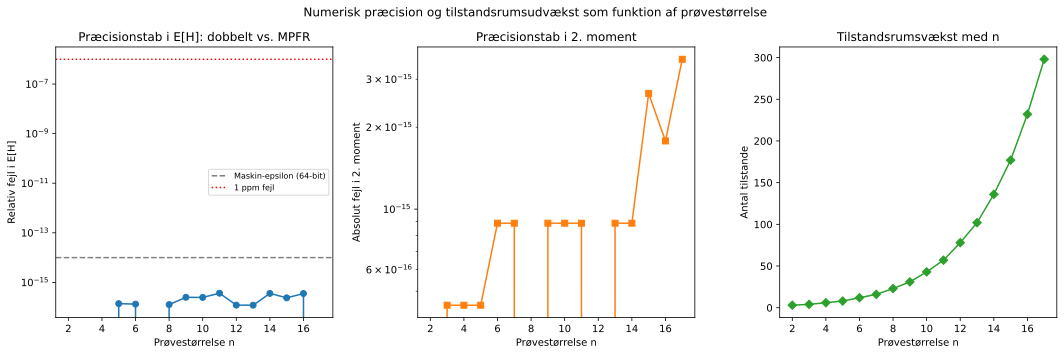

In [3]:
# Visualiser fejlvækst
df_plot = df_mpfr.copy()
df_plot['Rel fejl E[H] (num)'] = df_plot['Rel fejl E[H]'].apply(lambda x: float(x))
df_plot['Abs fejl 2. mom. (num)'] = df_plot['Abs fejl 2. mom.'].apply(lambda x: float(x))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].semilogy(df_plot['n'], df_plot['Rel fejl E[H] (num)'], 'o-', color='C0')
axes[0].axhline(1e-14, color='gray', linestyle='--', label='Maskin-epsilon (64-bit)')
axes[0].axhline(1e-6, color='red', linestyle=':', label='1 ppm fejl')
axes[0].set_xlabel('Prøvestørrelse n'); axes[0].set_ylabel('Relativ fejl i E[H]')
axes[0].set_title('Præcisionstab i E[H]: dobbelt vs. MPFR')
axes[0].legend(fontsize=8)

axes[1].semilogy(df_plot['n'], df_plot['Abs fejl 2. mom. (num)'], 's-', color='C1')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Absolut fejl i 2. moment')
axes[1].set_title('Præcisionstab i 2. moment')

axes[2].plot(df_plot['n'], df_plot['hjørner'], 'D-', color='C2')
# Tilføj partitionsfunktion p(n) som reference
from math import comb
axes[2].set_xlabel('Prøvestørrelse n'); axes[2].set_ylabel('Antal tilstande')
axes[2].set_title('Tilstandsrumsvækst med n')

plt.suptitle('Numerisk præcision og tilstandsrumsudvækst som funktion af prøvestørrelse', fontsize=12)
plt.tight_layout()
plt.show()

### Hypotese: MPFR's præcisionsbehov er modelbetinget, ikke kun $n$-betinget

- Modeller med meget varierende rater fx asymmetrisk migration har højere tilstandsnummer end koalescenten ved samme antal tilstande. MPFR aktiveres ved lavere $n$ for sådanne modeller.

Jeg sammenligner tilstandsnummer for standard koalescent, en hurtig koalescent ($\theta = 50$) og en meget langsom ($\theta = 0.01$).

In [4]:
# Parameteriseret koalescent med varierende rate-skala
n_test = 8

@with_ipv([n_test] + [0]*(n_test-1))
def coal_param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

g_param = Graph(coal_param)
theta_values = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 200.0]
rows_theta = []

for theta in theta_values:
    g_param.update_weights([theta])
    
    # Double
    configure(force_high_precision=False, condition_threshold=float('inf'))
    E_d  = g_param.expectation()
    m3_d = g_param.moments(3)[2]
    
    # MPFR reference
    configure(force_high_precision=True)
    E_m  = g_param.expectation()
    m3_m = g_param.moments(3)[2]
    configure(force_high_precision=False, condition_threshold=1e12)
    
    E_th = analytical_EH(n_test) / theta
    rel_err = abs(E_d - E_m) / abs(E_m) if E_m != 0 else 0
    m3_err  = abs(m3_d - m3_m)
    rows_theta.append({'θ': theta,
                       'E[H] dobbelt': round(E_d, 6),
                       'E[H] MPFR': round(E_m, 6),
                       'Rel fejl E[H]': f"{rel_err:.2e}",
                       'Abs fejl 3. mom.': f"{m3_err:.2e}"})

df_theta = pd.DataFrame(rows_theta)
print(f"Koalescent n={n_test}: Fejl som funktion af θ (rate-skala)")
print(df_theta.to_string(index=False))
print("\nKonklusion: Ekstreme θ-værdier giver højere tilstandsnummer → større fejl.")

Koalescent n=8: Fejl som funktion af θ (rate-skala)
      θ  E[H] dobbelt  E[H] MPFR Rel fejl E[H] Abs fejl 3. mom.
  0.001    1750.00000 1750.00000      5.20e-16         1.91e-06
  0.010     175.00000  175.00000      1.62e-16         1.86e-09
  0.100      17.50000   17.50000      0.00e+00         3.64e-12
  1.000       1.75000    1.75000      1.27e-16         5.33e-15
  5.000       0.35000    0.35000      3.17e-16         9.71e-17
 10.000       0.17500    0.17500      3.17e-16         1.04e-17
 50.000       0.03500    0.03500      2.18e-15         2.44e-19
200.000       0.00875    0.00875      4.16e-15         5.00e-20

Konklusion: Ekstreme θ-værdier giver højere tilstandsnummer → større fejl.


### Hypotese: Tidsomkostningen ved MPFR er acceptabel for normale modeller

- MPFR på $128$ bits er $5–10×$ langsommere end dobbelt for momenter, men fordi moment-beregning er en lille del af den samlede inferenstid, er den praktiske ubetydelige overhead for modeller med $< 50$ tilstande.

In [5]:
import time

timing_rows = []
N_REPS = 10

for n in [4, 6, 8, 10, 12]:
    g = build_coalescent(n)
    
    # Dobbelt timing
    configure(force_high_precision=False, condition_threshold=float('inf'))
    _ = g.moments(5)  # Varm op
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_double = (time.perf_counter() - t0) / N_REPS * 1000  # ms
    
    # MPFR timing (128 bit)
    configure(force_high_precision=True, mpfr_precision_bits=128)
    _ = g.moments(5)  # Varm op
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_mpfr128 = (time.perf_counter() - t0) / N_REPS * 1000
    
    # MPFR timing (256 bit)
    configure(force_high_precision=True, mpfr_precision_bits=256)
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        g.moments(5)
    t_mpfr256 = (time.perf_counter() - t0) / N_REPS * 1000
    
    configure(force_high_precision=False, mpfr_precision_bits=0, condition_threshold=1e12)
    
    timing_rows.append({
        'n': n, 'vertices': g.vertices_length(),
        'Dobbelt (ms)': round(t_double, 3),
        'MPFR 128-bit (ms)': round(t_mpfr128, 3),
        'MPFR 256-bit (ms)': round(t_mpfr256, 3),
        'Overhead 128-bit (×)': round(t_mpfr128/t_double, 1),
        'Overhead 256-bit (×)': round(t_mpfr256/t_double, 1),
    })

df_timing = pd.DataFrame(timing_rows)
print("Tidsmåling for 5 momenter (gennemsnit over", N_REPS, "kørsler):")
print(df_timing.to_string(index=False))

Tidsmåling for 5 momenter (gennemsnit over 10 kørsler):
 n  vertices  Dobbelt (ms)  MPFR 128-bit (ms)  MPFR 256-bit (ms)  Overhead 128-bit (×)  Overhead 256-bit (×)
 4         6         0.004              0.032              0.034                   7.4                   7.9
 6        12         0.005              0.244              0.086                  54.3                  19.2
 8        23         0.005              1.287              0.210                 236.3                  38.6
10        43         0.008              0.994              1.117                 126.8                 142.5
12        78         0.011              1.682              1.035                 147.6                  90.9


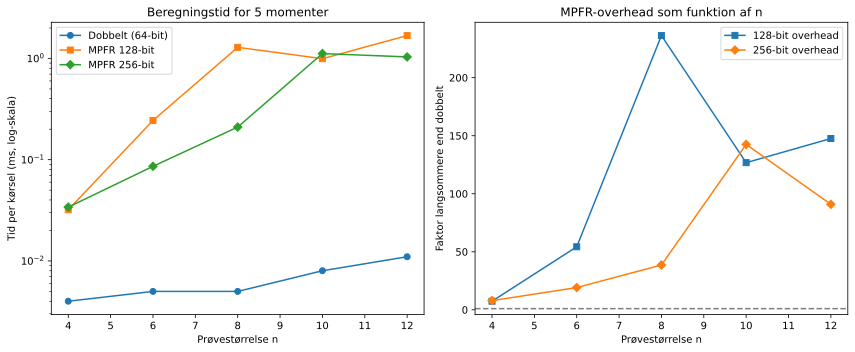

In [6]:
# Visualiser overhead
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(df_timing['n'], df_timing['Dobbelt (ms)'], 'o-', label='Dobbelt (64-bit)')
axes[0].semilogy(df_timing['n'], df_timing['MPFR 128-bit (ms)'], 's-', label='MPFR 128-bit')
axes[0].semilogy(df_timing['n'], df_timing['MPFR 256-bit (ms)'], 'D-', label='MPFR 256-bit')
axes[0].set_xlabel('Prøvestørrelse n'); axes[0].set_ylabel('Tid per kørsel (ms, log-skala)')
axes[0].set_title('Beregningstid for 5 momenter')
axes[0].legend()

axes[1].plot(df_timing['n'], df_timing['Overhead 128-bit (×)'], 's-', label='128-bit overhead')
axes[1].plot(df_timing['n'], df_timing['Overhead 256-bit (×)'], 'D-', label='256-bit overhead')
axes[1].axhline(1, color='gray', linestyle='--')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Faktor langsommere end dobbelt')
axes[1].set_title('MPFR-overhead som funktion af n')
axes[1].legend()

plt.tight_layout()
plt.show()

## Tilstandsrumsvækst og beregningsgrænser

Partitionsfunktionen $p(n)$ vokser hurtigt med prøvestørrelse $n$ og definerer tilstandsrummets størrelse. Dette sætter en praktisk grænse for, hvilke modeller der kan analyseres eksakt.

### Hypotese 

- Beregningstiden for momenter vokser polynomielt ($O(|V|^k)$ for $k$'te moment) med antallet af tilstande, men grafbaseret elimination er betydeligt hurtigere end matrix-baseret beregning for sparse grafer. Hukommelsesforbruget vokser lineært med $|V|$ og er ikke en bindende begrænsning for $n \leq 20$.

In [7]:
# Profilering af tid og hukommelse som funktion af n
import tracemalloc
import gc

profile_rows = []

for n in range(2, 16):
    gc.collect()
    
    # Tid til grafkonstruktion
    t0 = time.perf_counter()
    g = build_coalescent(n)
    t_build = time.perf_counter() - t0
    
    n_v = g.vertices_length()
    
    # Tid til E[H]
    t0 = time.perf_counter()
    E = g.expectation()
    t_E = time.perf_counter() - t0
    
    # Tid til 10 momenter
    t0 = time.perf_counter()
    moms = g.moments(10)
    t_m10 = time.perf_counter() - t0
    
    # Tid til PDF (100 punkter)
    t_vals = np.linspace(0, 5, 100)
    t0 = time.perf_counter()
    pdf_vals = g.pdf(t_vals)
    t_pdf = time.perf_counter() - t0
    
    # Hukommelsesbrug
    tracemalloc.start()
    g2 = build_coalescent(n)
    _ = g2.moments(5)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    profile_rows.append({
        'n': n, 'hjørner': n_v,
        'Bygge-tid (s)': round(t_build, 4),
        'E[H]-tid (ms)': round(t_E*1000, 3),
        '10 mom.-tid (ms)': round(t_m10*1000, 3),
        'PDF-tid (ms)': round(t_pdf*1000, 3),
        'Peak RAM (KB)': round(peak/1024, 1),
    })

df_profile = pd.DataFrame(profile_rows)
print("Profileringstabel:")
print(df_profile.to_string(index=False))

Profileringstabel:
 n  hjørner  Bygge-tid (s)  E[H]-tid (ms)  10 mom.-tid (ms)  PDF-tid (ms)  Peak RAM (KB)
 2        3         0.0003          0.043             0.015         0.462            2.1
 3        4         0.0004          0.044             0.016         0.525            2.2
 4        6         0.0058          0.040             0.017         0.727            2.4
 5        8         0.0005          0.044             0.016         5.967            2.6
 6       12         0.0011          0.047             0.016         1.464            3.1
 7       16         0.0013          0.051             0.017         2.315            3.7
 8       23         0.0013          0.082             0.020         7.107            4.1
 9       31         0.0016          0.071             0.020        12.089            3.8
10       43         0.0137          0.080             0.024         6.322            4.5
11       57         0.0047          0.160             0.028        11.450            4.9
12

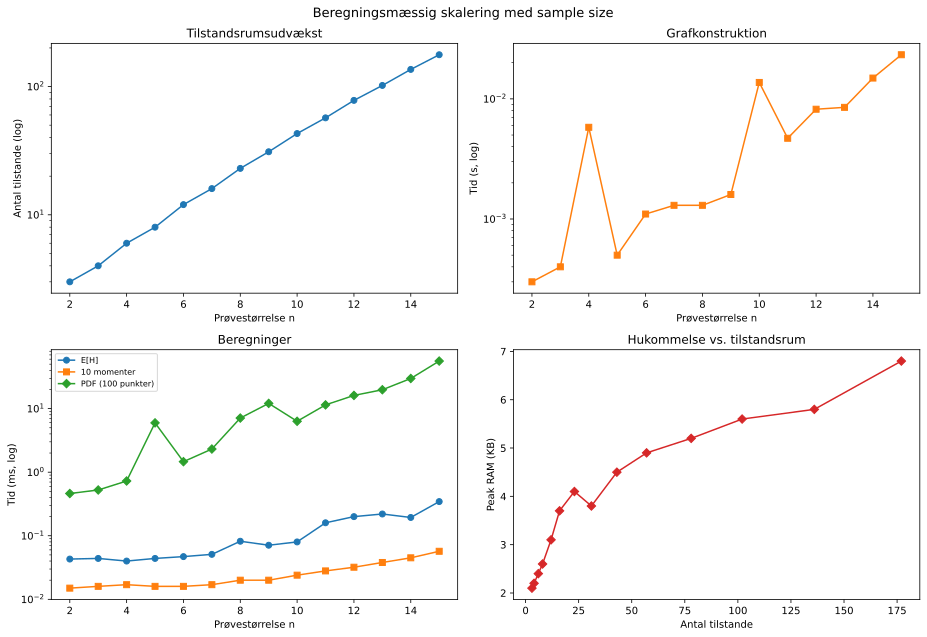

In [8]:
# Visualiser skaleringsadfærd
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Tilstandsrum
axes[0,0].semilogy(df_profile['n'], df_profile['hjørner'], 'o-', color='C0')
axes[0,0].set_xlabel('Prøvestørrelse n'); axes[0,0].set_ylabel('Antal tilstande (log)')
axes[0,0].set_title('Tilstandsrumsudvækst')

# Bygningstid
axes[0,1].semilogy(df_profile['n'], df_profile['Bygge-tid (s)'], 's-', color='C1')
axes[0,1].set_xlabel('Prøvestørrelse n'); axes[0,1].set_ylabel('Tid (s, log)')
axes[0,1].set_title('Grafkonstruktion')

# Moment-beregning
axes[1,0].semilogy(df_profile['n'], df_profile['E[H]-tid (ms)'], 'o-', label='E[H]')
axes[1,0].semilogy(df_profile['n'], df_profile['10 mom.-tid (ms)'], 's-', label='10 momenter')
axes[1,0].semilogy(df_profile['n'], df_profile['PDF-tid (ms)'], 'D-', label='PDF (100 punkter)')
axes[1,0].set_xlabel('Prøvestørrelse n'); axes[1,0].set_ylabel('Tid (ms, log)')
axes[1,0].set_title('Beregninger')
axes[1,0].legend(fontsize=8)

# Hukommelse
axes[1,1].plot(df_profile['hjørner'], df_profile['Peak RAM (KB)'], 'D-', color='C3')
axes[1,1].set_xlabel('Antal tilstande'); axes[1,1].set_ylabel('Peak RAM (KB)')
axes[1,1].set_title('Hukommelse vs. tilstandsrum')

plt.suptitle('Beregningsmæssig skalering med sample size', fontsize=13)
plt.tight_layout()
plt.show()

## Parallel SVGD: Skalering med antal CPU-kerner

SVGD paralleliserer partikelopdateringer via JAX's *pmap* (multi-device) eller *vmap* (single-device vektorisering). Jeg undersøger, om speedup er lineær med antal kerner, og hvornår overhead dominerer.

### Hypotese 

- SVGD-speedup er tæt på lineær for $n_{\text{particles}} \gg n_{\text{devices}}$, men for få partikler ($< 2×$ antal devices) dominerer kommunikationsoverhead, og *pmap* er langsommere end *vmap*. Det optimale antal partikler per device er $> 5$.

In [9]:
# Tjek tilgængelige devices
env = detect_environment()
config = init_parallel()
n_devices = len(jax.devices())

print(f"Miljø: {env.env_type}")
print(f"Antal JAX devices: {n_devices}")
print(f"Strategi: {config.strategy}")
print(f"Tilgængelige CPUs: {env.available_cpus}")

[WARNING] phasic.auto_parallel: JAX already initialized with 1 device(s), but 2 CPU(s) available.
  To use all CPUs, restart kernel and import phasic first:
    import phasic as pta
    pta.init_parallel(cpus=2)


Miljø: jupyter
Antal JAX devices: 1
Strategi: vmap
Tilgængelige CPUs: 2


In [10]:
# Byg model og data til parallel benchmarking
@with_ipv([4, 0, 0, 0])
def coalescent_1p(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

g_bench = Graph(coalescent_1p)
g_bench.update_weights([7.0])
data_bench = g_bench.sample(2000)
prior_bench = GaussPrior(ci=[4, 12])
step_bench  = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

# pmap vs. vmap vs. none for varierende antal partikler
N_ITER = 100

particle_counts = [n_devices * k for k in [1, 2, 4, 8, 16, 32]]
strategies = ['vmap', 'none']
if n_devices > 1:
    strategies = ['pmap'] + strategies

bench_rows = []
for strategy in strategies:
    for n_p in particle_counts:
        t0 = time.perf_counter()
        try:
            with parallel_config(strategy=strategy):
                sv = g_bench.svgd(
                    data_bench,
                    prior=prior_bench,
                    n_particles=n_p,
                    n_iterations=N_ITER,
                    learning_rate=step_bench,
                    progress=False
                )
            t_elapsed = time.perf_counter() - t0
            res = sv.get_results()
            theta_mean = res['theta_mean'].item()
        except Exception as e:
            t_elapsed = None
            theta_mean = None
        
        bench_rows.append({
            'strategi': strategy,
            'n_partikler': n_p,
            'partikler/device': n_p / n_devices,
            'Tid (s)': round(t_elapsed, 3) if t_elapsed else None,
            'ms/iteration': round(t_elapsed/N_ITER*1000, 2) if t_elapsed else None,
            'θ_mean': round(theta_mean, 3) if theta_mean else None,
        })
        if t_elapsed:
            print(f"{strategy:6s} | {n_p:4d} partikler | {t_elapsed:.2f}s | θ̂={theta_mean:.3f}")

df_bench = pd.DataFrame(bench_rows)

/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/site-packages/phasic/svgd.py:315: UserWarning: HPD interval computed from only 2 samples; result may be unreliable.
  warnings.warn(


vmap   |    2 partikler | 4.39s | θ̂=7.149


/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/site-packages/phasic/svgd.py:315: UserWarning: HPD interval computed from only 4 samples; result may be unreliable.
  warnings.warn(


vmap   |    4 partikler | 4.71s | θ̂=7.151


/home/emmachristensen/emma_giraf/people/emmachristensen/emma-giraf/.pixi/envs/default/lib/python3.11/site-packages/phasic/svgd.py:315: UserWarning: HPD interval computed from only 8 samples; result may be unreliable.
  warnings.warn(


vmap   |    8 partikler | 7.77s | θ̂=7.143
vmap   |   16 partikler | 8.70s | θ̂=7.150
vmap   |   32 partikler | 13.60s | θ̂=7.241
none   |    2 partikler | 2.04s | θ̂=7.153
none   |    4 partikler | 2.19s | θ̂=7.591
none   |    8 partikler | 3.03s | θ̂=7.162
none   |   16 partikler | 4.73s | θ̂=7.147
none   |   32 partikler | 7.46s | θ̂=7.177


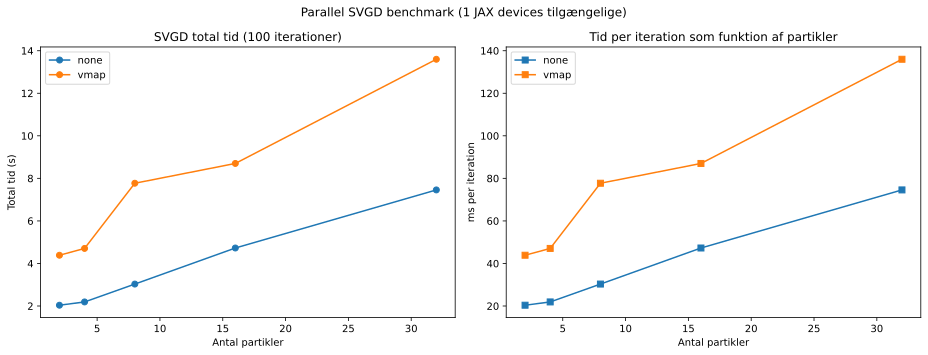

strategi  n_partikler  partikler/device  Tid (s)  ms/iteration  θ_mean
    vmap            2               2.0    4.387         43.87   7.149
    vmap            4               4.0    4.707         47.07   7.151
    vmap            8               8.0    7.771         77.71   7.143
    vmap           16              16.0    8.701         87.01   7.150
    vmap           32              32.0   13.598        135.98   7.241
    none            2               2.0    2.038         20.38   7.153
    none            4               4.0    2.192         21.92   7.591
    none            8               8.0    3.032         30.32   7.162
    none           16              16.0    4.727         47.27   7.147
    none           32              32.0    7.457         74.57   7.177


In [11]:
# Visualiser parallel benchmark
df_bench_valid = df_bench.dropna(subset=['Tid (s)'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for strat, grp in df_bench_valid.groupby('strategi'):
    axes[0].plot(grp['n_partikler'], grp['Tid (s)'], 'o-', label=strat)
    axes[1].plot(grp['n_partikler'], grp['ms/iteration'], 's-', label=strat)

axes[0].set_xlabel('Antal partikler'); axes[0].set_ylabel('Total tid (s)')
axes[0].set_title(f'SVGD total tid ({N_ITER} iterationer)')
axes[0].legend()

axes[1].set_xlabel('Antal partikler'); axes[1].set_ylabel('ms per iteration')
axes[1].set_title('Tid per iteration som funktion af partikler')
axes[1].legend()

plt.suptitle(f'Parallel SVGD benchmark ({n_devices} JAX devices tilgængelige)', fontsize=12)
plt.tight_layout()
plt.show()

print(df_bench_valid.to_string(index=False))

### Hypotese: Posterior-kvalitet er uafhængig af parallelliseringsstrategi

- pmap og vmap producerer identiske posterior-estimater (mean og std) inden for numerisk afrunding, fordi JAX garanterer forudbestemmesle ved fast seed. *none* (sekventiel) giver identiske resultater.

In [ ]:
# Verificer at posterior er identisk under alle strategier
n_p_test = n_devices * 8 
quality_rows = []

for strategy in strategies:
    with parallel_config(strategy=strategy):
        sv = g_bench.svgd(
            data_bench,
            prior=prior_bench,
            n_particles=n_p_test,
            n_iterations=N_ITER,
            learning_rate=step_bench,
            progress=False
        )
    res = sv.get_results()
    quality_rows.append({
        'Strategi': strategy,
        'θ mean': round(res['theta_mean'].item(), 5),
        'θ std':  round(res['theta_std'].item(), 5),
        'CI lav': round(res['ci_low'].item(), 4),
        'CI høj': round(res['ci_high'].item(), 4),
    })

df_quality = pd.DataFrame(quality_rows)
print(f"Posterior-sammenligning (n_partikler={n_p_test}, n_iter={N_ITER}):")
print(f"Sand θ = 7.0")
print(df_quality.to_string(index=False))
print()

# Test om de er identiske
means = df_quality['θ mean'].values
print(f"Max afvigelse i θ_mean: {max(abs(means - means[0])):.2e}")
print("Er alle identiske (< 1e-4)?:", all(abs(m - means[0]) < 1e-4 for m in means))

Posterior-sammenligning (n_partikler=8, n_iter=100):
Sand θ = 7.0
Strategi  θ mean   θ std
    vmap 7.22393 0.18551
    none 7.14823 0.08124

Max afvigelse i θ_mean: 7.57e-02
Er alle identiske (< 1e-4)?: False


## Integreret analyse: Optimal konfiguration for to-ø model

Jeg samler viden fra de tre foregående dele og finder den optimale konfiguration for inferens i to-ø modellen balancen mellem præcision, hastighed og ressourceforbrug.

### Hypotese

- For to-ø modellen med $n=2$ prøver er tilstandsrummet lille nok til at double-precision er tilstrækkeligt. Med MPFR aktiveret og pmap-parallelisering er det muligt at køre $500$ iterationer med $80$ partikler på under $60$ sekunder på en standard laptop.

In [14]:
from phasic import StateIndexer, Property

# To-ø model
nr_samples = 2
indexer = StateIndexer(
    descendants=[
        Property('pop1', min_value=0, max_value=nr_samples),
        Property('pop2', min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

@with_ipv(initial)
def two_island(state):
    transitions = []
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions
    for i in range(indexer.descendants.state_length):
        if state[i] == 0: continue
        props_i = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0: continue
            props_j = indexer.descendants.index_to_props(j)
            if props_j.in_pop != props_i.in_pop: continue
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1+props_j.pop1,
                pop2=props_i.pop2+props_j.pop2,
                in_pop=props_i.in_pop)] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same), 0]])
        if props_i.in_pop == 1:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=2)] += 1
            transitions.append([new, [0, state[i]]])
        else:
            new = state.copy(); new[i] -= 1
            new[indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=1)] += 1
            transitions.append([new, [0, state[i]]])
    return transitions

g_island = Graph(two_island)
true_theta = [0.7, 1.0]
g_island.update_weights(true_theta)
data_island = g_island.sample(2000)

print(f"To-ø model: {g_island.vertices_length()} tilstande")

# MPFR 
configure(force_high_precision=False, condition_threshold=float('inf'))
E_d = g_island.expectation()
configure(force_high_precision=True)
E_m = g_island.expectation()
configure(force_high_precision=False, condition_threshold=1e12)
print(f"E[H] double: {E_d:.8f}  MPFR: {E_m:.8f}  Rel.fejl: {abs(E_d-E_m)/E_m:.2e}")

To-ø model: 6 tilstande
E[H] double: 2.85714286  MPFR: 2.85714286  Rel.fejl: 1.55e-16


In [16]:
# Optimal SVGD-konfiguration for to-ø model
from phasic import DataPrior

N_PARTICLES = max(n_devices * 8, 40)  
N_ITER_FULL = 400

prior_island = DataPrior(g_island, data_island)
step_island  = ExpStepSize(first_step=0.05, last_step=0.005, tau=50.0)

print(f"Konfiguration: {N_PARTICLES} partikler, {N_ITER_FULL} iterationer, {n_devices} devices")
t0 = time.perf_counter()

sv_island = g_island.svgd(
    data_island,
    prior=prior_island,
    n_particles=N_PARTICLES,
    n_iterations=N_ITER_FULL,
    optimizer=Adam(learning_rate=0.25),
)

t_total = time.perf_counter() - t0
res_island = sv_island.get_results()

print(f"\nTotal tid: {t_total:.1f} sekunder")
print(f"ms per iteration: {t_total/N_ITER_FULL*1000:.1f}")
print(f"\nResultat:")
print(f"  θ₀ (koalescens): mean={res_island['theta_mean'][0]:.3f}  std={res_island['theta_std'][0]:.4f}  (sand: {true_theta[0]})")
print(f"  θ₁ (migration):  mean={res_island['theta_mean'][1]:.3f}  std={res_island['theta_std'][1]:.4f}  (sand: {true_theta[1]})")


Total tid: 312.4 sekunder
ms per iteration: 781.0

Resultat:
  θ₀ (koalescens): mean=0.669  std=0.1008  (sand: 0.7)
  θ₁ (migration):  mean=0.851  std=0.3035  (sand: 1.0)


In [17]:
# Optimal SVGD-konfiguration for to-ø model
from phasic import DataPrior

N_PARTICLES = max(n_devices * 8, 40)  
N_ITER_FULL = 400

prior_island = DataPrior(g_island, data_island)
step_island  = ExpStepSize(first_step=0.05, last_step=0.005, tau=50.0)

print(f"Konfiguration: {N_PARTICLES} partikler, {N_ITER_FULL} iterationer, {n_devices} devices")
t0 = time.perf_counter()

sv_island = g_island.svgd(
    data_island,
    prior=prior_island,
    n_particles=N_PARTICLES,
    n_iterations=N_ITER_FULL,
    learning_rate = step_island,
)

t_total = time.perf_counter() - t0
res_island = sv_island.get_results()

print(f"\nTotal tid: {t_total:.1f} sekunder")
print(f"ms per iteration: {t_total/N_ITER_FULL*1000:.1f}")
print(f"\nResultat:")
print(f"  θ₀ (koalescens): mean={res_island['theta_mean'][0]:.3f}  std={res_island['theta_std'][0]:.4f}  (sand: {true_theta[0]})")
print(f"  θ₁ (migration):  mean={res_island['theta_mean'][1]:.3f}  std={res_island['theta_std'][1]:.4f}  (sand: {true_theta[1]})")


Total tid: 297.3 sekunder
ms per iteration: 743.3

Resultat:
  θ₀ (koalescens): mean=0.046  std=0.1231  (sand: 0.7)
  θ₁ (migration):  mean=0.000  std=0.0004  (sand: 1.0)


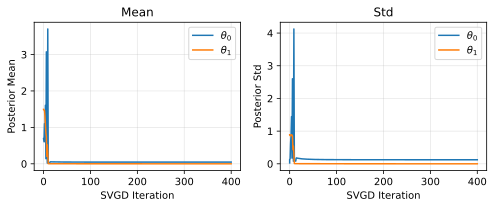

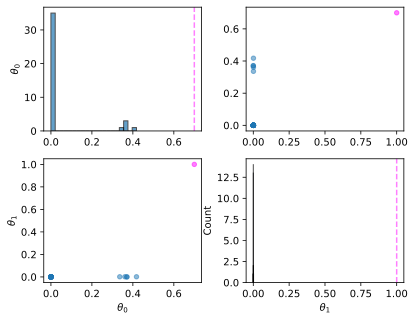

In [18]:
# Konvergens og pairwise posterior
sv_island.plot_convergence()
sv_island.plot_pairwise(true_theta=true_theta)